<a href="https://colab.research.google.com/github/kerols999/Amazon-Sales-Insights-Dashboard/blob/main/Copy_of_Welcome_to_Colab.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

In [ ]:
from google.colab import files
uploaded = files.upload()


Saving crimes.csv to crimes.csv


In [ ]:
uploaded.keys()

dict_keys(['crimes.csv'])

In [ ]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns

In [ ]:
df = pd.read_csv("crimes.csv")
print(df.head())


       DR_NO   Date Rptd    DATE OCC  TIME OCC    AREA NAME  \
0  220314085  2022-07-22  2020-05-12      1110    Southwest   
1  222013040  2022-08-06  2020-06-04      1620      Olympic   
2  220614831  2022-08-18  2020-08-17      1200    Hollywood   
3  231207725  2023-02-27  2020-01-27       635  77th Street   
4  220213256  2022-07-14  2020-07-14       900      Rampart   

         Crm Cd Desc  Vict Age Vict Sex Vict Descent Weapon Desc  Status Desc  \
0  THEFT OF IDENTITY        27        F            B         NaN  Invest Cont   
1  THEFT OF IDENTITY        60        M            H         NaN  Invest Cont   
2  THEFT OF IDENTITY        28        M            H         NaN  Invest Cont   
3  THEFT OF IDENTITY        37        M            H         NaN  Invest Cont   
4  THEFT OF IDENTITY        79        M            B         NaN  Invest Cont   

                                  LOCATION  
0  2500 S  SYCAMORE                     AV  
1  3300    SAN MARINO                   ST  

In [ ]:
print(df.isnull().sum())

DR_NO                0
Date Rptd            0
DATE OCC             0
TIME OCC             0
AREA NAME            0
Crm Cd Desc          0
Vict Age             0
Vict Sex            11
Vict Descent        10
Weapon Desc     112213
Status Desc          0
LOCATION             0
dtype: int64


In [ ]:
df['Vict Sex'] = df['Vict Sex'].fillna('Unknwn')
# بما إن القيم المفقودة غالباً تعني عدم وجود سلاح، هنستبدلها بـ "Unknown" أو "No Weapon"
df['Weapon Desc'] = df['Weapon Desc'].fillna('Unknown')

In [ ]:
print("Missing values in Weapon Desc:", df['Weapon Desc'].isnull().sum())
print("Missing values in Vict Sex:", df['Vict Sex'].isnull().sum())

Missing values in Weapon Desc: 0
Missing values in Vict Sex: 0


In [ ]:
# عرض أول 5 صفوف بعد التعديل
print(df[['Vict Sex', 'Weapon Desc']].head())

  Vict Sex Weapon Desc
0        F     Unknown
1        M     Unknown
2        M     Unknown
3        M     Unknown
4        M     Unknown


In [ ]:
# Convert the integer time to a string, pad with zeros, and format as HH:MM
df['Time_Formatted'] = df['TIME OCC'].astype(str).str.zfill(4)
df['Time_Formatted'] = pd.to_datetime(df['Time_Formatted'], format='%H%M').dt.time

print(df[['TIME OCC', 'Time_Formatted']].head())

   TIME OCC Time_Formatted
0      1110       11:10:00
1      1620       16:20:00
2      1200       12:00:00
3       635       06:35:00
4       900       09:00:00


In [ ]:
# تحويل الوقت من أرقام زي (1300) إلى أرقام تعبر عن الساعات فقط (13)
df['Hour'] = df['TIME OCC'] // 100

# دالة لتصنيف الوقت لفترات زمنية (الصبح، الظهر، المساء، الليل)
def get_time_period(hour):
    if 5 <= hour < 12:
        return 'Morning'    # الصباح
    elif 12 <= hour < 17:
        return 'Afternoon'  # الظهر/العصر
    elif 17 <= hour < 21:
        return 'Evening'    # المساء
    else:
        return 'Night'      # الليل

# تطبيق الدالة وتكوين عمود جديد باسم Time_Period
df['Time_Period'] = df['Hour'].apply(get_time_period)

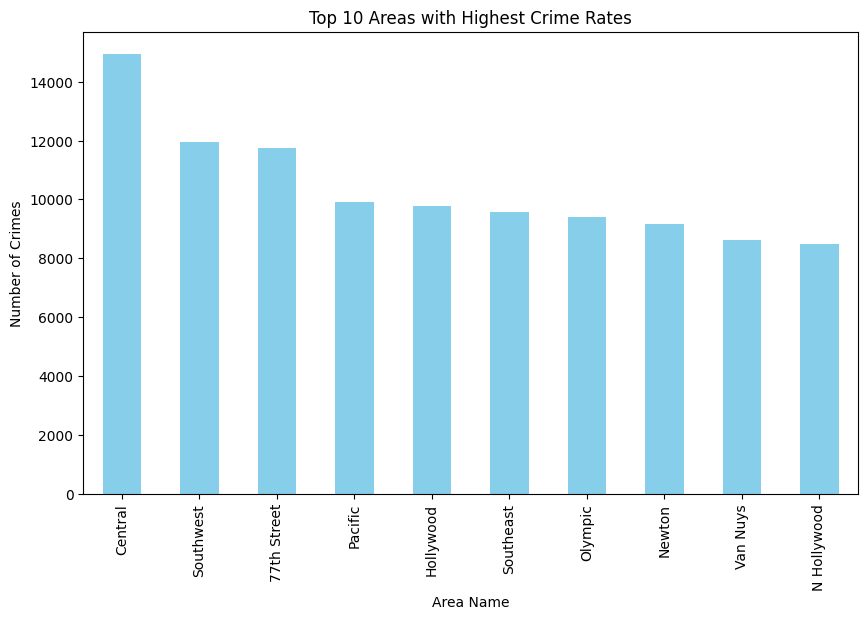

In [ ]:
# 1. رسم بياني لأكثر 10 مناطق فيها جرائم
plt.figure(figsize=(10,6))
df['AREA NAME'].value_counts().head(10).plot(kind='bar', color='skyblue')
plt.title('Top 10 Areas with Highest Crime Rates')
plt.xlabel('Area Name')
plt.ylabel('Number of Crimes')
plt.show()

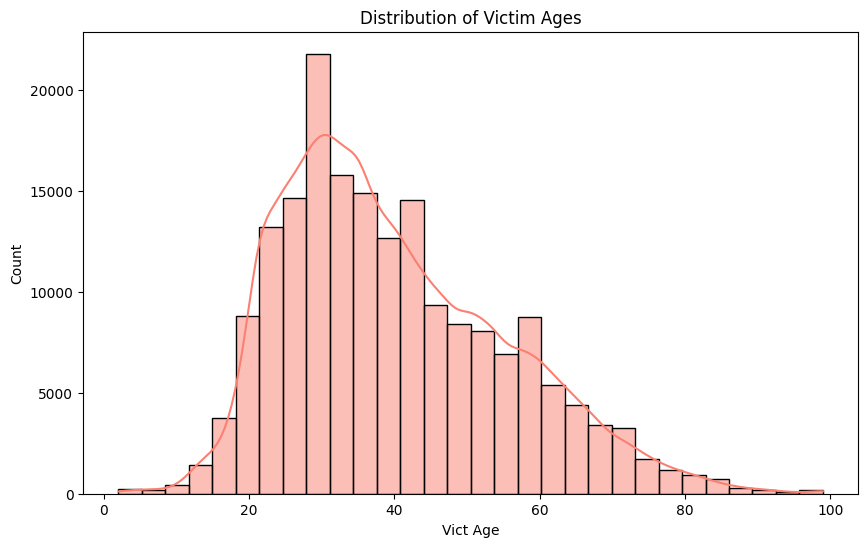

In [ ]:
# 2. توزيع أعمار الضحايا
plt.figure(figsize=(10,6))
sns.histplot(df['Vict Age'], bins=30, kde=True, color='salmon')
plt.title('Distribution of Victim Ages')
plt.show()

/tmp/ipykernel_1183/3243195686.py:6: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.countplot(x='Time_Period', data=df,


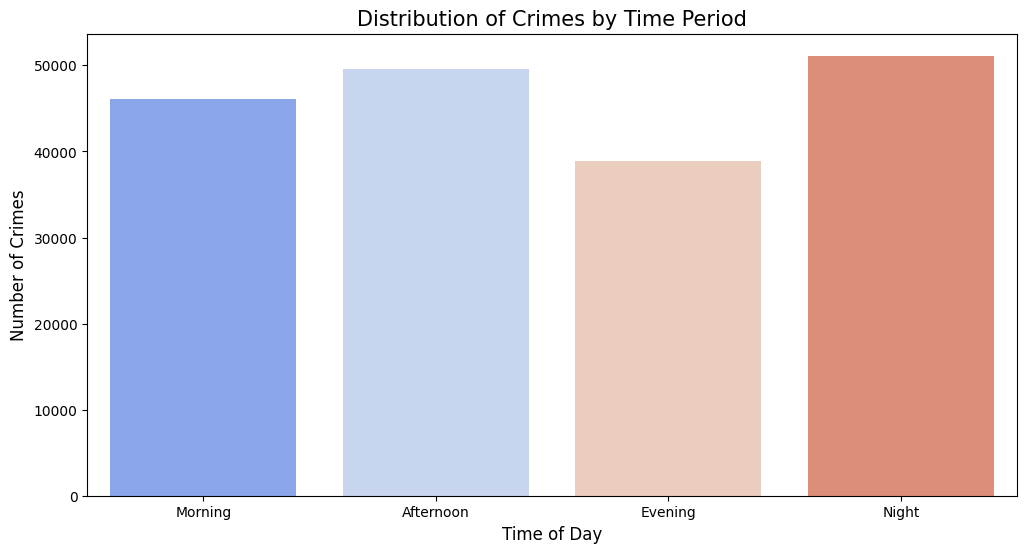

--- تحليل فترات اليوم ---
Time_Period
Night        51122
Afternoon    49626
Morning      46037
Evening      38930
Name: count, dtype: int64


In [ ]:
# --- 2. رسم البيانات ---

plt.figure(figsize=(12, 6))

# رسم بياني يوضح عدد الجرائم في كل فترة زمنية
sns.countplot(x='Time_Period', data=df,
              order=['Morning', 'Afternoon', 'Evening', 'Night'],
              palette='coolwarm')

# إضافة العناوين للرسم البياني
plt.title('Distribution of Crimes by Time Period', fontsize=15)
plt.xlabel('Time of Day', fontsize=12)
plt.ylabel('Number of Crimes', fontsize=12)

plt.show()

# --- 3. ملخص سريع بالأرقام ---
print("--- تحليل فترات اليوم ---")
print(df['Time_Period'].value_counts())

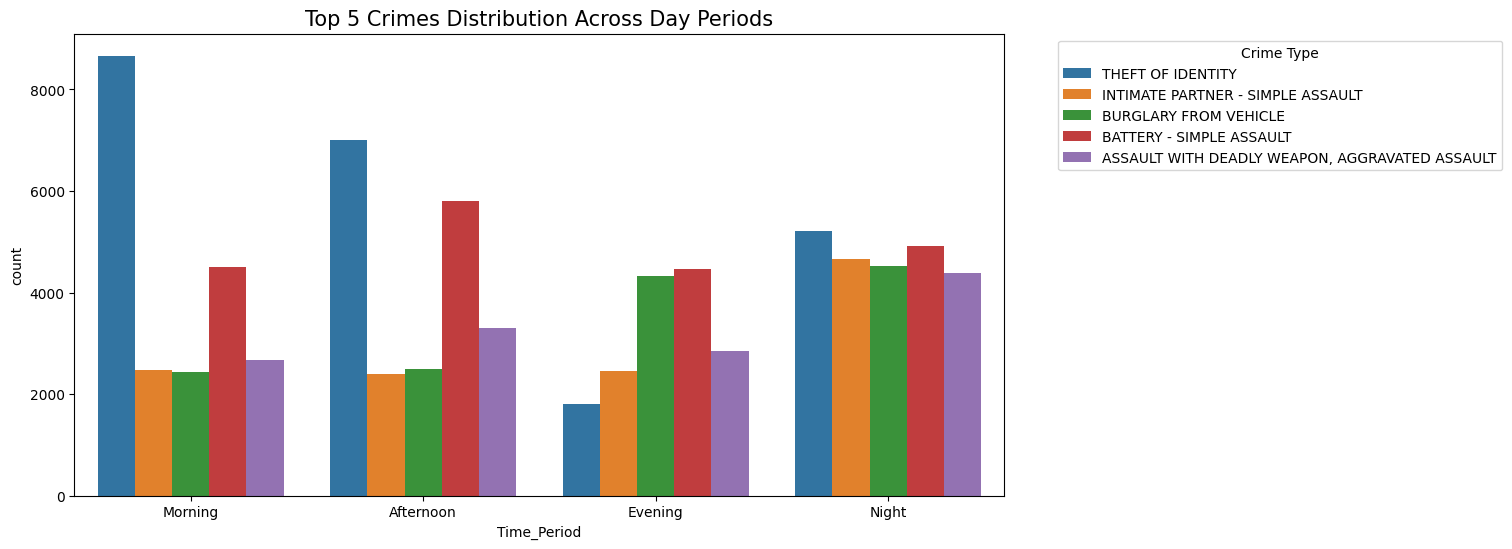

In [ ]:
# 1. تحليل العلاقة بين نوع الجريمة وفترة اليوم
# هنختار أكتر 5 جرائم تكراراً عشان الرسمة تكون واضحة
top_5_crimes = df['Crm Cd Desc'].value_counts().head(5).index
df_top_crimes = df[df['Crm Cd Desc'].isin(top_5_crimes)]

plt.figure(figsize=(12, 6))
# رسم بياني يوضح توزيع أشهر 5 جرائم على فترات اليوم
sns.countplot(data=df_top_crimes, x='Time_Period', hue='Crm Cd Desc',
              order=['Morning', 'Afternoon', 'Evening', 'Night'])

plt.title('Top 5 Crimes Distribution Across Day Periods', fontsize=15)
plt.legend(title='Crime Type', bbox_to_anchor=(1.05, 1), loc='upper left')
plt.show()

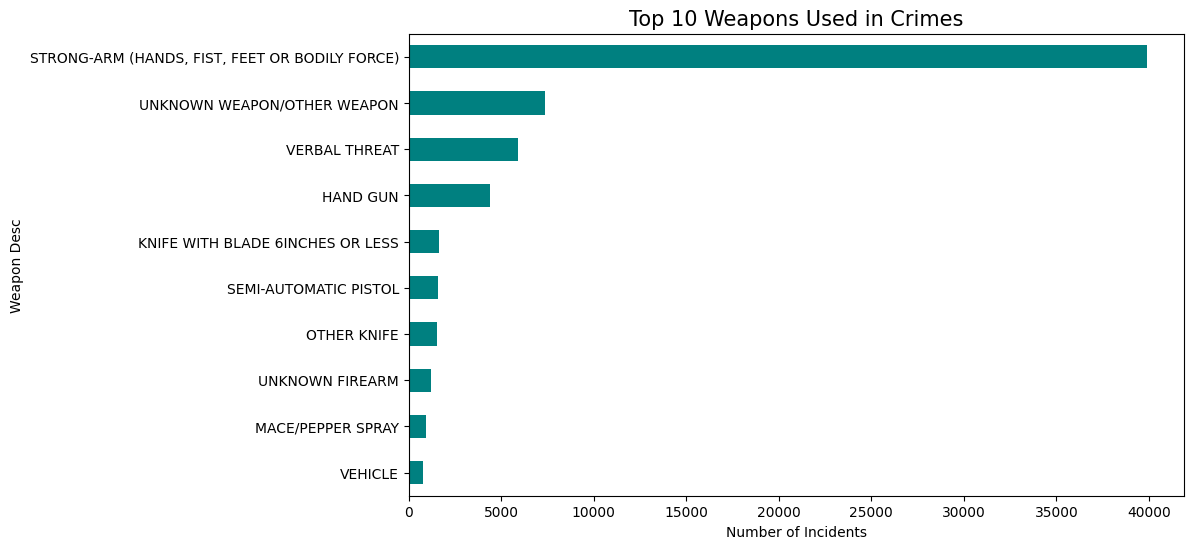

In [ ]:
# 2. تحليل الأسلحة الأكثر استخداماً (باستثناء الـ Unknown اللي عدلناها)
plt.figure(figsize=(10, 6))
# هنجيب أكتر 10 أسلحة مستخدمة بعيداً عن "غير معروف"
top_weapons = df[df['Weapon Desc'] != 'Unknown']['Weapon Desc'].value_counts().head(10)
top_weapons.plot(kind='barh', color='teal')

plt.title('Top 10 Weapons Used in Crimes', fontsize=15)
plt.xlabel('Number of Incidents')
plt.gca().invert_yaxis() # عشان الترتيب يكون من الأكبر للأصغر
plt.show()

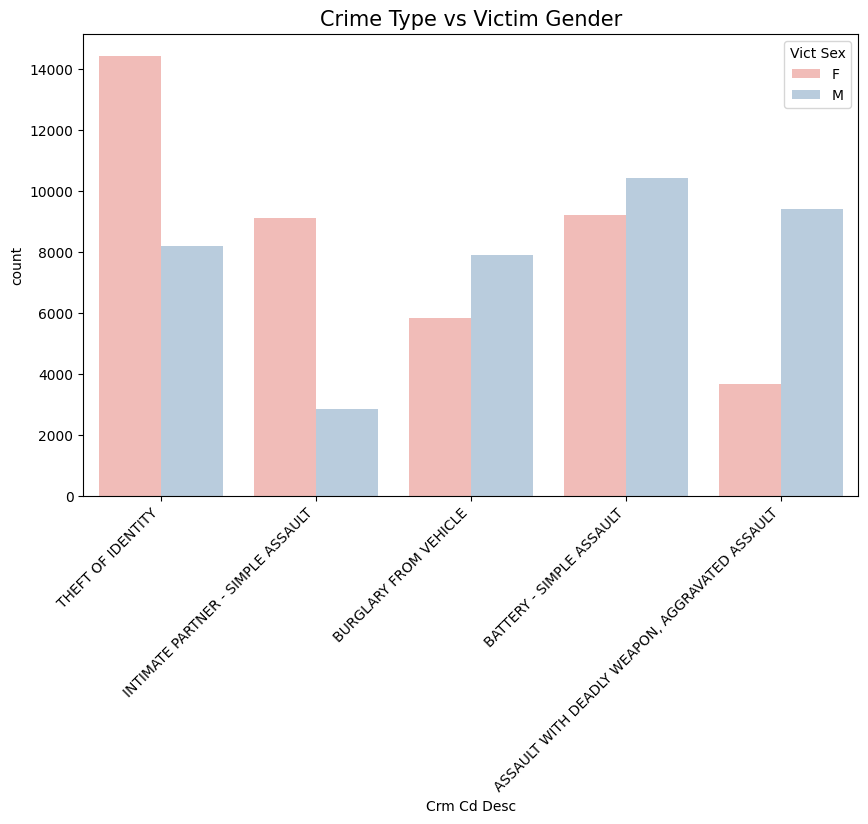

In [ ]:
# 3. مقارنة بين جنس الضحية ونوع الجريمة
plt.figure(figsize=(10, 6))
# مقارنة بين الذكور (M) والإناث (F) في أكتر 5 جرائم
sns.countplot(data=df_top_crimes[df_top_crimes['Vict Sex'].isin(['M', 'F'])],
              x='Crm Cd Desc', hue='Vict Sex', palette='Pastel1')

plt.xticks(rotation=45, ha='right')
plt.title('Crime Type vs Victim Gender', fontsize=15)
plt.show()

In [ ]:
df.to_csv('cleaned_crimes_data.csv', index=False)